## Socioeconomic predictors for Anxiety Analysis : A Data Reuse Example for NIH HEAL Datasets

This notebook demonstrates **data reuse** by combining two independent HEAL studies — **HDP00619** and **HDP01233** — both of which measured anxiety using the GAD-2 instrument alongside demographic variables. Neither study alone has enough participants for robust subgroup analysis, but together they form a dataset of 281 records that we use to explore how age, sex, ethnicity, marital status, and employment relate to anxiety severity.

---
### Research Questions

1.  Is there a relationship between demographic variables and total anxiety scores?

2.  Can we predict anxiety severity (GAD total score) using demographic features such as age, sex, ethnicity, marital status, and employment?

3.  Can we classify individuals into high vs. low anxiety groups based on their demographic characteristics?

4.  Which demographic and socioeconomic factors are most strongly associated with anxiety levels, and which are most important for predicting anxiety classification?

---

### 1. Imports and Setup

In this step, we import the tools needed for data analysis and modeling.

- **Pandas** is used to handle tables of data (like Excel sheets).
- **NumPy** helps with numerical calculations.
- **Matplotlib** is used for creating visualizations such as graphs and charts.
- **train_test_split** from scikit-learn helps divide the data into training and testing sets for building models.

We also run a notebook called `analysis_functions.ipynb`, which contains helper functions for:
- Cleaning the datasets
- Plotting graphs
- Training machine learning models

Finally, we configure plotting settings to make the charts look clean and readable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Run the analysis functions notebook to load all functions
%run analysis_functions.ipynb

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100

---
### 1a. Placeholder for Platform-specific code to get data from HDP00619 and HDP01233
---

---
### What Are Common Data Elements — and Why Do They Make Data Reuse Possible?
---
A **Common Data Element (CDE)** is a standardized definition for a variable: its name, data type, allowed values, and what those values mean. HEAL has defined CDEs for variables commonly used across pain and opioid use disorder research — including GAD-2 anxiety scores, age, sex, ethnicity, marital status, and employment status.

The file `heal-mappings.json` in the data folder that was downloaded from HEAL Semantic Search is the bridge that connects HEAL's standard variable names to the specific column names used in each study. For example:

| HEAL Standard Variable | HDP00619 column | HDP01233 column |
|---|---|---|
| `Sex` | `gender` | `sex` |
| `MARISTAT` | `marstat` | `maristat` |
| `GAD2FeelNervScale` | `gad701` | `gad2feelnervscale` |

**Without CDEs**, you would need to manually read the data dictionary for each study, guess which columns correspond to the same measurement, reconcile different value encodings, and hope nothing was missed. That process doesn't scale beyond 2–3 studies.

**With CDEs**, the mapping file does that work programmatically — making the combination process repeatable, auditable, and scalable to any number of studies that adopt the same standards.

The cleaning steps below use these mappings explicitly: the code looks up the study-specific column name from the standard ID, applies any necessary recoding, and then renames the column to the standard name — so both datasets end up with identical column names ready to merge.

---
### 2. Load, Standardize and Clean Data
---
Here we load data from two different studies:

- **HDP00619** — a CSV file with screening visit data
- **HDP01233** — two Excel files: one for demographics, one for GAD-2 responses

We first load the raw files and inspect them, then apply the CDE mappings to clean and standardize each dataset. After cleaning, both datasets will share identical column names and value encodings — a prerequisite for combining them.

In [2]:
print("Loading raw datasets...")
mappings     = load_mappings("../data/heal-mappings.json")
df_619_raw   = load_dataset("../data/HDP00619.csv")
df_1233_demo = load_dataset("../data/HDP01233_Demographics.xlsx")
df_1233_gad  = load_dataset("../data/HDP01233_Gad2.xlsx")

print(f"\nHDP00619:              {df_619_raw.shape[0]:>4} rows, {df_619_raw.shape[1]:>3} columns")
print(f"HDP01233 demographics: {df_1233_demo.shape[0]:>4} rows, {df_1233_demo.shape[1]:>3} columns")
print(f"HDP01233 GAD-2:        {df_1233_gad.shape[0]:>4} rows, {df_1233_gad.shape[1]:>3} columns")

print("\nHDP00619 — raw data (first 3 rows):")
display(df_619_raw.head(3))

print("\nHDP01233 demographics — raw data (first 3 rows):")
display(df_1233_demo.head(3))

print("\nHDP01233 GAD-2 — raw data (first 3 rows):")
display(df_1233_gad.head(3))

Loading raw datasets...

HDP00619:              1488 rows, 692 columns
HDP01233 demographics:  203 rows,  19 columns
HDP01233 GAD-2:         404 rows,   5 columns

HDP00619 — raw data (first 3 rows):


,scrid,redcap_event_name,screener_welcome_timestamp,studydesc,screener_welcome_complete,age,scr_gender,height,howadp,onbup,...,saftey_checklist_v2___2,saftey_checklist_v2___3,saftey_checklist_v2___4,saftey_checklist_v2___5,safety_rest_v2,safety_restsani_v2,safety_restcheck_v2___1,safety_restcheck_v2___2,safety_restcheck_v2___3,postcovid_safety_checklist_complete
0,1,screener_arm_1,NaN,1.0,2.0,24.0,1.0,69.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,screener_arm_1,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,screener_arm_1,NaN,1.0,2.0,38.0,0.0,63.0,3.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



HDP01233 demographics — raw data (first 3 rows):


,subject_id,sex,height,weight,bmi,edulevel,empstat,maristat,incmlvl,disabinsind,paindur,surveylanguage,demruca1,demruca2,ethnic,Race,agegrp,age,gender_identity
0,sub-100-01,2,69.0,259.0,38.243436,5.0,2.0,1.0,1,1.0,72.0,1,1.0,1.0,2.0,1,8,71,2
1,sub-100-02,1,74.0,280.0,35.945946,3.0,3.0,3.0,10,0.0,144.0,1,1.0,1.0,2.0,2,8,65,1
2,sub-100-03,2,70.0,170.0,24.389796,4.0,2.0,1.0,2,1.0,132.0,1,1.0,1.0,2.0,7,7,59,2



HDP01233 GAD-2 — raw data (first 3 rows):


,subject_id,visit,gad2feelnervscale,gad2notstopwryscale,gad2totalscore
0,sub-100-01,visit 1,2,1,3
1,sub-100-01,visit 2,3,1,4
2,sub-100-02,visit 1,1,0,1


Notice that the two studies use **different column names** for the same variables (`gender` vs `sex`, `gad701` vs `gad2feelnervscale`, `marstat` vs `maristat`), and HDP00619 has many columns not needed for this analysis. The cleaning step below uses the CDE mappings to select, rename, and recode only the relevant columns — producing a standardized dataset from each study.

In [3]:
print("Cleaning HDP00619...")
df_619 = clean_hdp00619(df_619_raw.copy(), mappings)
print(f"  -> {len(df_619)} records after cleaning")

print("\nHDP00619 — after cleaning (first 3 rows):")
display(df_619.head(3))

print("\nCleaning HDP01233...")
df_1233 = clean_hdp01233(df_1233_demo.copy(), df_1233_gad.copy(), mappings)
print(f"  -> {len(df_1233)} records after cleaning")

print("\nHDP01233 — after cleaning (first 3 rows):")
display(df_1233.head(3))

Cleaning HDP00619...
  Variable mappings for HDP00619:
    Age                        -> 'age'
    Sex                        -> 'gender'
    ETHNIC                     -> 'ethnic'
    MARISTAT                   -> 'marstat'
    EMPSTAT                    -> 'empstat'
    GAD2FeelNervScale          -> 'gad701'
    GAD2NotStopWryScale        -> 'gad702'
  -> 82 records after cleaning

HDP00619 — after cleaning (first 3 rows):


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,GAD2FeelNervScale,GAD2NotStopWryScale,gad_total,higher_anxiety
2,38,2,2,3,2,0,0,0,0
4,24,2,2,3,2,3,3,6,1
7,24,2,2,3,2,0,0,0,0



Cleaning HDP01233...
  Variable mappings for HDP01233:
    Age                        -> 'age'
    Sex                        -> 'sex'
    ETHNIC                     -> 'ethnic'
    MARISTAT                   -> 'maristat'
    EMPSTAT                    -> 'empstat'
    GAD2FeelNervScale          -> 'gad2feelnervscale'
    GAD2NotStopWryScale        -> 'gad2notstopwryscale'
  -> 199 records after cleaning

HDP01233 — after cleaning (first 3 rows):


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,GAD2FeelNervScale,GAD2NotStopWryScale,gad_total,higher_anxiety
0,71,2,2,1,2,2,1,3,0
2,65,1,2,3,3,1,0,1,0
4,59,2,2,1,2,0,1,1,0


Both datasets now use the **HEAL standard variable names** (`Age`, `Sex`, `ETHNIC`, `MARISTAT`, `EMPSTAT`, `GAD2FeelNervScale`, `GAD2NotStopWryScale`) and consistent integer encodings. This standardization is what makes combining them valid.

### Comparing the datasets

We generate a scatter plot to visually compare the two datasets.

This helps us:
- Check whether the datasets look similar
- Identify differences in distributions
- Detect any unusual patterns or outliers

Visualization is useful before combining datasets to ensure they are compatible.

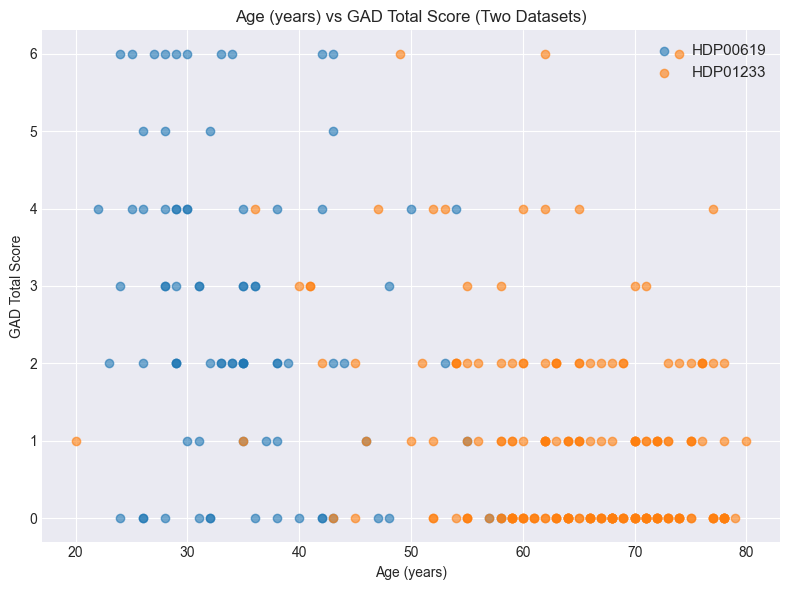

In [4]:
# Scatter plot comparing both datasets
plot_scatter_comparison(df_619, df_1233, variable='Age', variable_label='Age (years)')

---
### 3. Merge the Datasets
---
After cleaning, both datasets share the same structure. We preview them side by side before combining to confirm they are compatible, then concatenate into a single dataset for analysis.

A larger combined sample (N=281) gives us more statistical power than either study alone (HDP00619: N=82, HDP01233: N=199).

In [5]:
print(f"HDP00619 cleaned — {len(df_619)} records:")
display(df_619.head(3))

print(f"\nHDP01233 cleaned — {len(df_1233)} records:")
display(df_1233.head(3))

print("\nBoth datasets share the same columns and encodings — ready to combine.")

HDP00619 cleaned — 82 records:


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,GAD2FeelNervScale,GAD2NotStopWryScale,gad_total,higher_anxiety
2,38,2,2,3,2,0,0,0,0
4,24,2,2,3,2,3,3,6,1
7,24,2,2,3,2,0,0,0,0



HDP01233 cleaned — 199 records:


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,GAD2FeelNervScale,GAD2NotStopWryScale,gad_total,higher_anxiety
0,71,2,2,1,2,2,1,3,0
2,65,1,2,3,3,1,0,1,0
4,59,2,2,1,2,0,1,1,0



Both datasets share the same columns and encodings — ready to combine.


In [6]:
# Merge datasets
print("Merging datasets...")
df = pd.concat([df_619, df_1233], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")
print(f"Total records: {len(df)}")
df.head()

Merging datasets...
Combined dataset shape: (281, 9)
Total records: 281


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,GAD2FeelNervScale,GAD2NotStopWryScale,gad_total,higher_anxiety
0,38,2,2,3,2,0,0,0,0
1,24,2,2,3,2,3,3,6,1
2,24,2,2,3,2,0,0,0,0
3,25,1,2,3,1,2,2,4,0
4,38,2,2,3,2,1,1,2,0


---
### 4. Research Question 1: Is There a Relationship Between Demographic Variables and Anxiety?
---
This section addresses **Research Question 1**: Is there a relationship between demographic variables and total anxiety scores?

The panel below shows each demographic variable against the **GAD total score**. Age uses a scatter plot with a linear regression line; categorical variables use box plots showing the GAD score distribution per group.

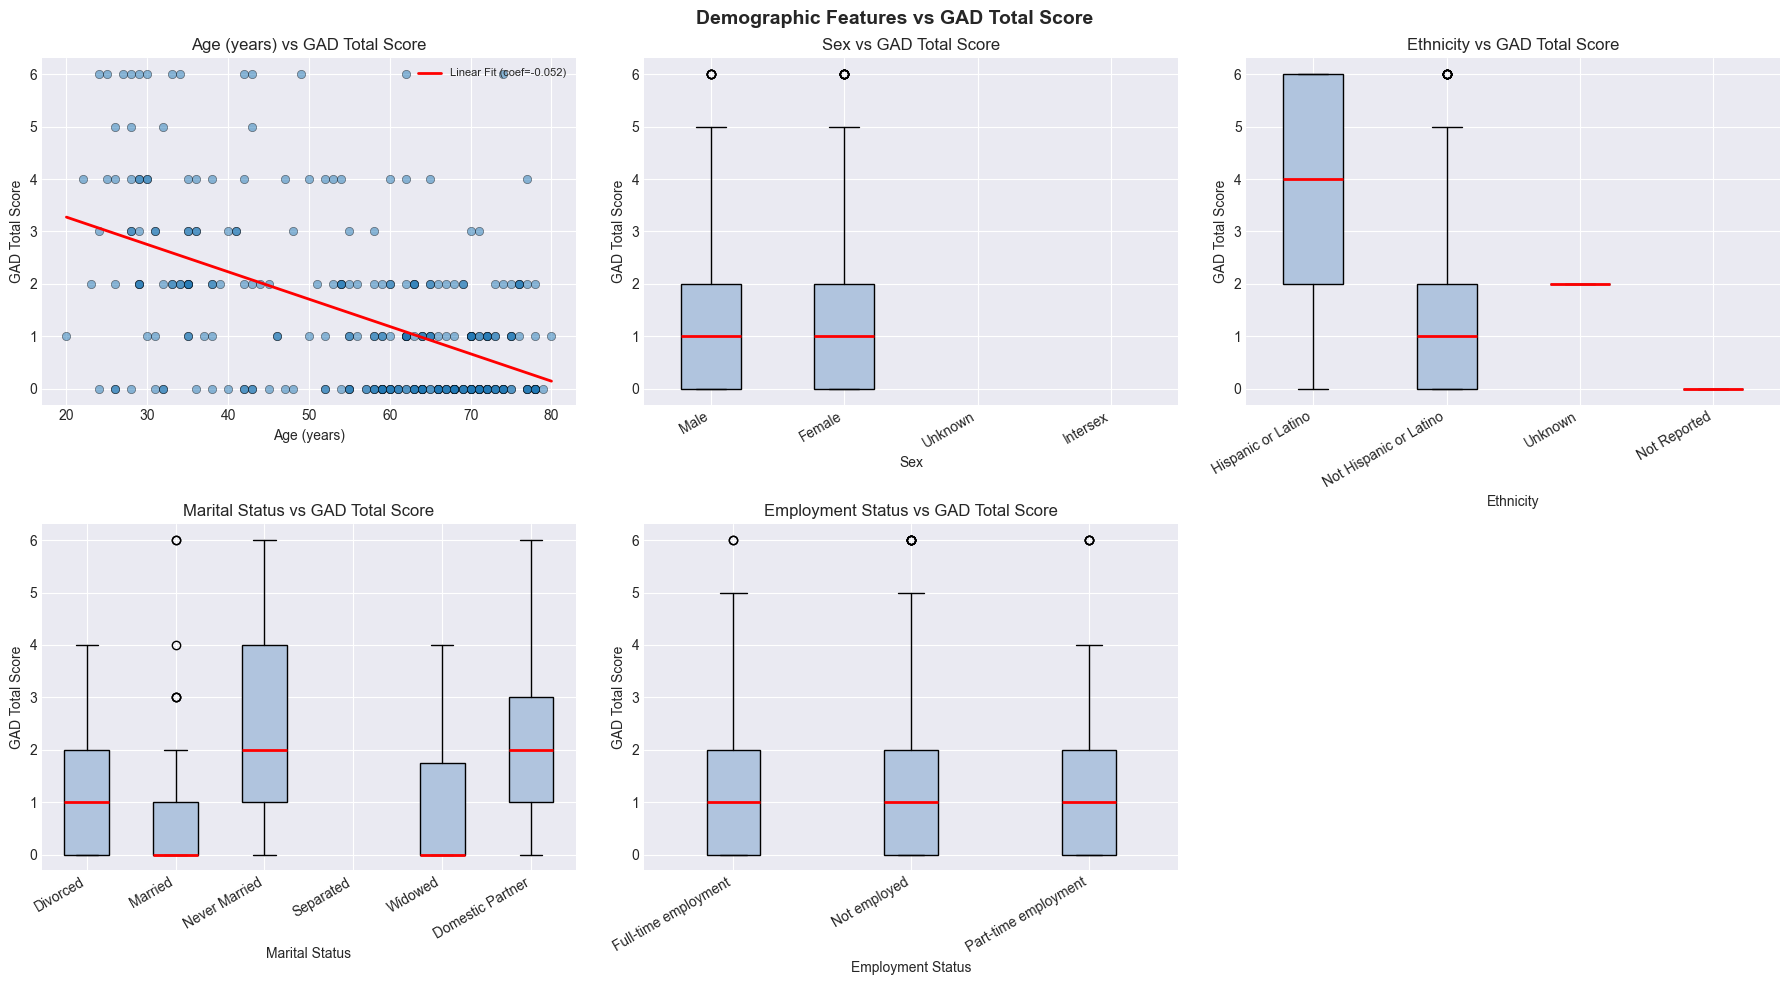

In [7]:
# Label maps derived from HEAL standard variable definitions in heal-mappings.json
# Note: standard enum keys may differ from cleaned data values — see enum alignment
# output above. Where they differ, the standard labels are shown for reference.
features = [
    ("Age",     "Age (years)",       None),
    ("Sex",     "Sex",               get_standard_labels("Sex",      mappings)),
    ("ETHNIC",  "Ethnicity",         get_standard_labels("ETHNIC",   mappings)),
    ("MARISTAT", "Marital Status",   get_standard_labels("MARISTAT", mappings)),
    ("EMPSTAT", "Employment Status", get_standard_labels("EMPSTAT",  mappings)),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Demographic Features vs GAD Total Score", fontsize=14, fontweight="bold")

for ax, (feature, label, label_map) in zip(axes.flat, features):
    plot_feature_vs_gad(df, feature, label, ax=ax, label_map=label_map)

axes.flat[-1].set_visible(False)  # hide unused 6th subplot

plt.tight_layout()
plt.show()

---
### 4b. Cluster Analysis: Do Patterns Emerge Across the Two Populations?
---

Since the two studies recruited clinically distinct populations — **pain patients** (HDP00619) and **OUD patients** (HDP01233) — it is worth asking whether these groups occupy separate regions of the feature space, or whether anxiety-driven patterns cut across study boundaries.

We use **PCA** to project the demographic + GAD features into 2D for visualization, and **K-means (k=3)** to find natural groupings. Two views of the same PCA projection are shown: colored by study origin, and colored by cluster assignment. If clusters largely align with study membership, the two populations are demographically distinct. If clusters cut across studies, it suggests shared anxiety-demographic profiles that transcend clinical context — a direct argument for the value of data reuse.


PCA variance explained: PC1=30.6%, PC2=17.0%


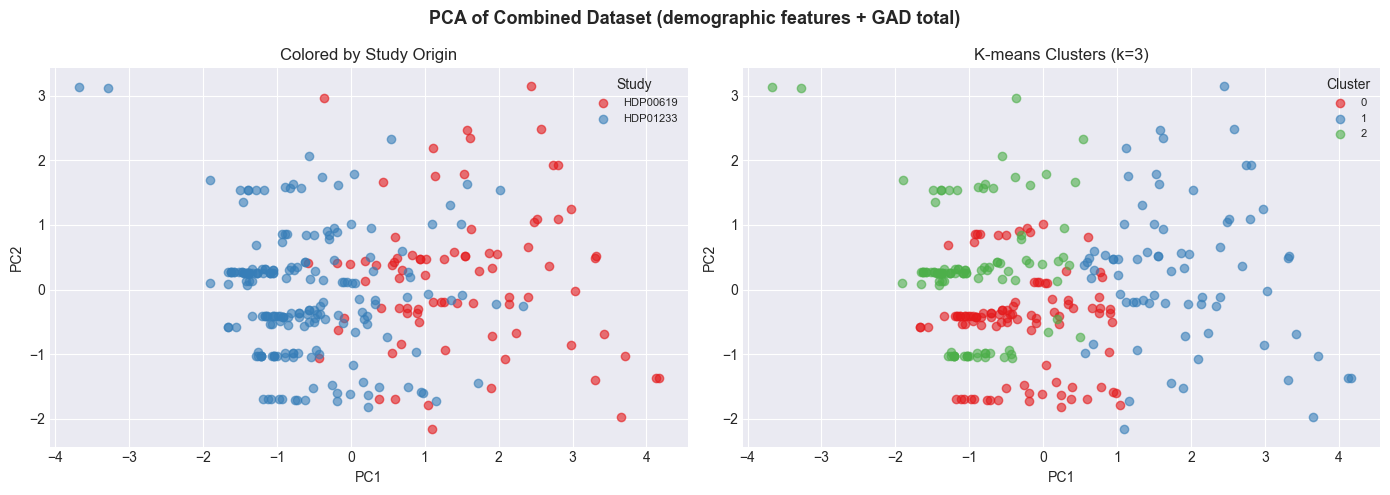

In [8]:
cluster_features = ['Age', 'Sex', 'ETHNIC', 'MARISTAT', 'EMPSTAT', 'gad_total']
study_labels = ['HDP00619'] * len(df_619) + ['HDP01233'] * len(df_1233)

cluster_labels, pca_coords, var_explained = run_kmeans(df, cluster_features, n_clusters=3)
print(f"PCA variance explained: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA of Combined Dataset (demographic features + GAD total)", fontsize=13, fontweight='bold')
plot_pca_clusters(pca_coords, study_labels,           'Study',   'Colored by Study Origin',     ax=axes[0])
plot_pca_clusters(pca_coords, cluster_labels.tolist(), 'Cluster', 'K-means Clusters (k=3)',      ax=axes[1])
plt.tight_layout()
plt.show()

In [9]:
print("Cluster profiles — mean feature values per cluster:")
display(get_cluster_profiles(df, cluster_features, cluster_labels))

df_tmp = df.copy()
df_tmp['study']   = study_labels
df_tmp['cluster'] = cluster_labels
print("\nCluster composition by study (row proportions):")
display(pd.crosstab(df_tmp['cluster'], df_tmp['study'], normalize='index').round(2))

Cluster profiles — mean feature values per cluster:


,Age,Sex,ETHNIC,MARISTAT,EMPSTAT,gad_total
Cluster,,,,,,
0,60.14,2.00,1.99,2.29,1.88,0.79
1,36.96,1.45,1.86,3.49,2.10,3.44
2,65.39,1.00,2.05,2.25,1.93,0.56



Cluster composition by study (row proportions):


study,HDP00619,HDP01233
cluster,,
0,0.13,0.87
1,0.82,0.18
2,0.08,0.92


**Interpreting this result:** Check two things: (1) Does the left panel show clear separation by study? If yes, the populations are demographically distinct. (2) Do the clusters in the right panel align with study membership, or do they cut across it? Clusters that mix both studies around shared anxiety or demographic profiles are evidence that the combined dataset reveals patterns neither study could surface alone.

---
### 5. Prepare Data for Modeling
---
Machine learning models require numeric input features (X) and a target variable (y).

Here we create:
- **X** → demographic variables (Age, Sex, Ethnicity, Marital Status, Employment Status)
- **y_linear** → continuous anxiety score (`gad_total`) for regression
- **y_logistic** → binary high-anxiety indicator (`higher_anxiety`) for classification

We also address **class imbalance**: only a small fraction of participants meet the high-anxiety threshold (GAD total ≥ 6). If ignored, models can achieve high accuracy by simply predicting "low anxiety" for everyone — which is useless in practice. We handle this in two ways:
1. **Stratified train/test split** — ensures the same proportion of high-anxiety cases appears in both the training and test sets, so the test set actually contains cases to evaluate
2. **Balanced class weights** — instructs the models to penalize errors on the minority class more heavily, so they are incentivized to learn to identify high-anxiety individuals

In [10]:
# Prepare features and targets
X, y_linear, y_logistic = prepare_model_data(df)

print("Features used in modeling:")
print(list(X.columns))
print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print("A sample of the dataset:")
X.head()

Features used in modeling:
['Age', 'Sex', 'MARISTAT', 'EMPSTAT', 'ETHNIC']

Number of features: 5
Number of samples: 281
A sample of the dataset:


,Age,Sex,MARISTAT,EMPSTAT,ETHNIC
0,38,2,3,2,2
1,24,2,3,2,2
2,24,2,3,2,2
3,25,1,3,1,2
4,38,2,3,2,2


In [11]:
# Split data into training and test sets
# stratify=y_logistic ensures both sets have the same proportion of high-anxiety cases
X_train, X_test, y_train_lin, y_test_lin = train_test_split(
    X, y_linear, test_size=0.2, random_state=42, stratify=y_logistic
)

_, _, y_train_log, y_test_log = train_test_split(
    X, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic
)

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")
print(f"\nHigh-anxiety rate — train: {y_train_log.mean():.1%}  |  test: {y_test_log.mean():.1%}")
print("(These should be similar, confirming the stratified split worked.)")

Training set size: 224
Test set size:     57

High-anxiety rate — train: 4.5%  |  test: 5.3%
(These should be similar, confirming the stratified split worked.)


---
### 6. Research Question 2: Linear Regression for Predicting Anxiety using Demographic Features
---
This section addresses **Research Question 2**: Can we predict anxiety severity (GAD total score) using demographic features such as age, sex, ethnicity, marital status, and employment?

#### Training linear regression model

Linear regression predicts **continuous anxiety scores**.

The model learns how demographic variables influence anxiety level using the GAD total score.

We evaluate using:
- **R² Score** → how well the model explains variation
- **RMSE** → average prediction error

This helps understand predictive power.

In [12]:
# Train linear regression model
lin_results = train_linear_regression(X_train, y_train_lin, X_test, y_test_lin)

print("Linear Regression Results")
print("=" * 50)
print(f"R² Score: {lin_results['r2']:.4f}")
print(f"RMSE: {lin_results['rmse']:.4f}")

Linear Regression Results
R² Score: 0.3186
RMSE: 1.3593


**Interpreting this result:** An R² of around 0.17 means demographic features explain roughly 17% of the variation in GAD total scores. That's a modest but real signal — it tells us demographics matter, but that most of what drives an individual's anxiety is not captured by these variables alone (clinical history, treatment type, and psychological factors likely explain far more). The RMSE of ~1.5 means predictions are off by about 1.5 points on average on a 0–6 scale.

#### Visualize Linear Regression Coefficients

This visualization also addresses **Research Question 4**: Which demographic and socioeconomic factors are most strongly associated with anxiety levels?

The coefficient plot shows the direction and strength of each feature's association with GAD total score:

- **Positive coefficient** → higher values of that feature predict higher anxiety
- **Negative coefficient** → higher values predict lower anxiety
- **Larger magnitude** → stronger association

This helps identify which variables are most meaningfully linked to anxiety.

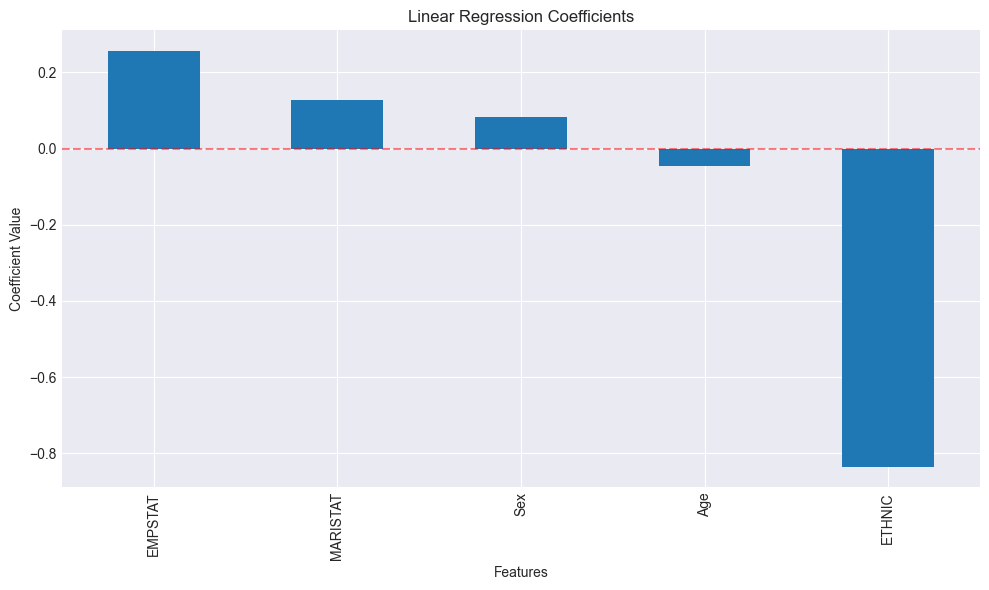


Linear Regression Coefficients:
EMPSTAT     0.255900
MARISTAT    0.128800
Sex         0.082902
Age        -0.046500
ETHNIC     -0.835257
dtype: float64


In [13]:
# Plot linear regression coefficients
coefficients = plot_linear_coefficients(lin_results['model'], X)
print("\nLinear Regression Coefficients:")
print(coefficients)

**Interpreting this result:** Features with larger absolute coefficients have a stronger linear association with anxiety scores. A positive coefficient means higher values of that variable predict higher anxiety; negative means lower. Note that these are *associations*, not causes — a coefficient for ethnicity, for example, likely reflects structural and social factors rather than ethnicity itself.

---
### 7. Research Question 3: Classifying Individuals into High vs. Low Anxiety
---
This section addresses **Research Question 3**: Can we classify individuals into high vs. low anxiety groups based on their demographic characteristics?

#### Training Logistic Regression Model

Logistic regression predicts **categories**, such as:
- High anxiety
- Low anxiety

Evaluation metrics:
- Accuracy
- Confusion matrix
- Classification report (precision, recall, F1)

This model helps classify participants into risk groups.

In [14]:
# Train logistic regression model
log_results = train_logistic_regression(X_train, y_train_log, X_test, y_test_log)

print("Logistic Regression Results")
print("=" * 50)
print(f"Accuracy: {log_results['accuracy']:.4f}")
print("\nConfusion Matrix:")
print(log_results['confusion_matrix'])
print("\nClassification Report:")
print(log_results['classification_report'])

Logistic Regression Results
Accuracy: 0.7544

Confusion Matrix:
[[41 13]
 [ 1  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85        54
           1       0.13      0.67      0.22         3

    accuracy                           0.75        57
   macro avg       0.55      0.71      0.54        57
weighted avg       0.93      0.75      0.82        57



**Interpreting this result:** Look beyond the headline accuracy. With balanced class weights, the confusion matrix should now show the model identifying some high-anxiety individuals rather than predicting everyone as low-anxiety. Precision, recall, and F1 for the high-anxiety class (class 1) are the meaningful metrics here — accuracy alone is misleading when classes are imbalanced.

---
### 8. Decision Tree Classifier
---
Decision trees split the data into branches based on features.

Advantages:
- Easy to interpret
- Shows decision rules
- Handles nonlinear relationships

We measure performance using accuracy.

In [15]:
# Train decision tree
tree_results = train_decision_tree(X_train, y_train_log, X_test, y_test_log, X)

print("Decision Tree Results")
print("=" * 50)
print(f"Accuracy: {tree_results['accuracy']:.4f}")

Decision Tree Results
Accuracy: 0.9474


#### Visualizing Decision Tree Structure

This visualization shows:
- How decisions are made
- Which features are used first
- Decision thresholds

This is helpful for explaining results to non-technical audiences.

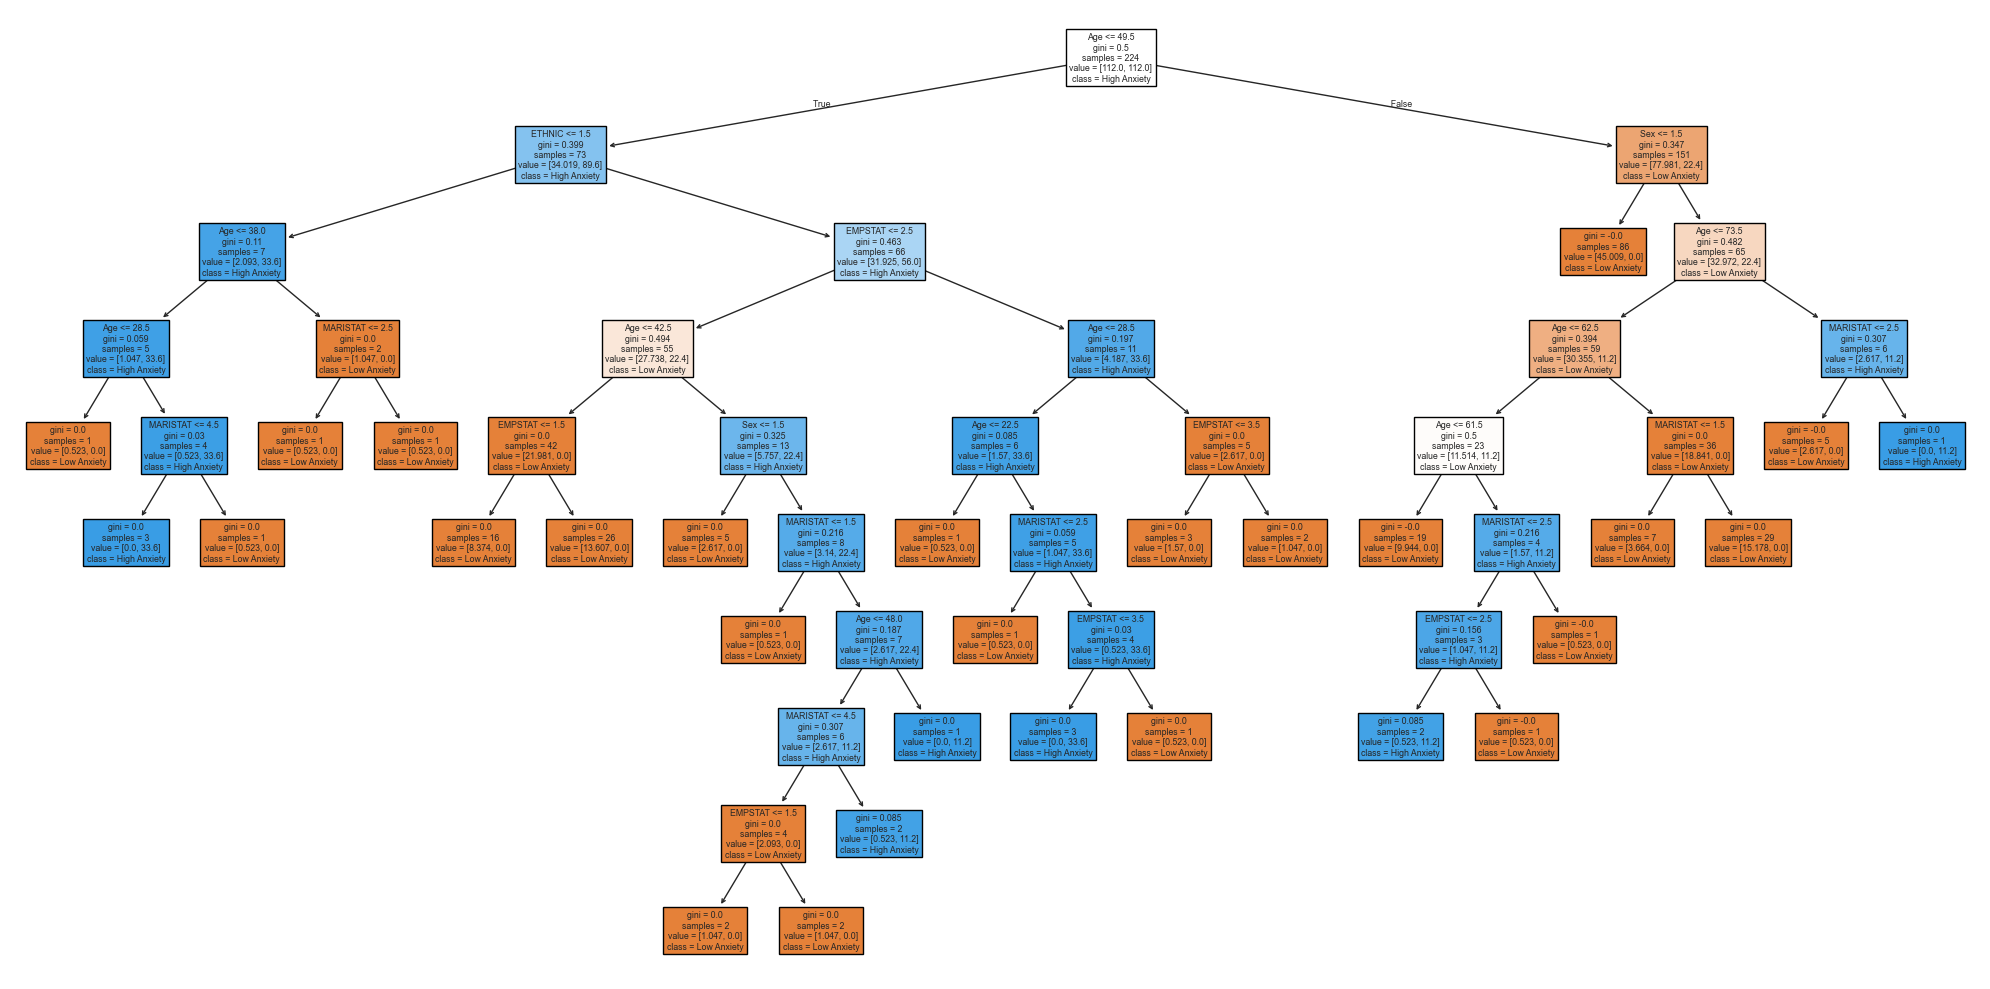

In [16]:
# Visualize decision tree
plot_decision_tree(tree_results['model'], tree_results['feature_names'])

**Interpreting this result:** The decision tree accuracy can be compared to logistic regression to see whether a non-linear decision boundary improves classification. The tree visualization (below) shows the exact rules the model learned — a useful feature when explaining findings to clinicians or non-technical stakeholders.

---
### 9. Research Question 4: Which Factors Are Most Associated with and Predictive of Anxiety?
---
This section addresses **Research Question 4**: Which demographic and socioeconomic factors are most strongly associated with anxiety levels, and which are most important for predicting anxiety classification?

Random forest feature importance provides a complementary view to the regression coefficients: while coefficients measure linear association with the continuous GAD score, feature importance reflects how useful each variable is for splitting the data into high vs. low anxiety groups across many decision trees.

In [17]:
# Train random forest
rf_results = train_random_forest(X_train, y_train_log, X_test, y_test_log)

print("Random Forest Results")
print("=" * 50)
print(f"Accuracy: {rf_results['accuracy']:.4f}")

Random Forest Results
Accuracy: 0.9474


**Interpreting this result:** Random forest aggregates many decision trees to reduce overfitting. Compare its confusion matrix to the logistic regression — if it better captures high-anxiety cases, the ensemble approach is providing value. Accuracy alone is not the right metric here given the class imbalance.

#### Identifying Most Important Features

Random forest calculates feature importance.

This shows:
- Which variables influence predictions most
- Key drivers of anxiety
- Variables worth further investigation

This step helps summarize findings.

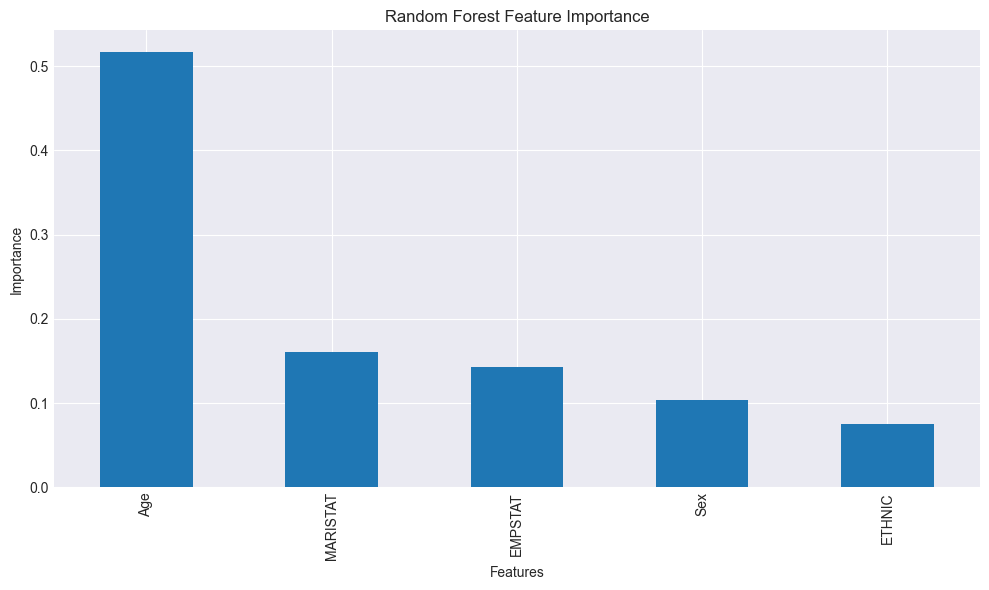


Feature Importance:
Age         0.516668
MARISTAT    0.161165
EMPSTAT     0.142664
Sex         0.103925
ETHNIC      0.075578
dtype: float64


In [18]:
# Plot feature importance
importance = plot_feature_importance(rf_results['model'], X)
print("\nFeature Importance:")
print(importance)

**Interpreting this result:** Feature importance scores sum to 1. A dominant score for Age means the model found age to be the most useful splitter across all trees. However, high importance does not imply causation, and importance can be inflated for continuous variables (like age) relative to binary ones. The relative ranking across features is more meaningful than the absolute scores.

---
### 10. Answers to Research Questions

Based on our analysis, here are the answers to our research questions:

In [19]:
print("=" * 80)
print("ANSWERS TO RESEARCH QUESTIONS")
print("=" * 80)
print()

print("Q1: Is there a relationship between demographic variables and total anxiety scores?")
print()
print("ANSWER: Yes. The feature panel (Section 4) shows:")
print("  - Age has a slight negative linear relationship with GAD total score")
print("  - Categorical features (Sex, Ethnicity, Marital Status, Employment)")
print("    show varying GAD distributions across groups — see box plots for details")
print()

print("Q2: Can we predict anxiety severity (GAD total score) using demographic features?")
print()
print(f"ANSWER: Yes, with moderate success. The Linear Regression model achieved:")
print(f"  - R\u00b2 Score: {lin_results['r2']:.4f}")
print(f"  - RMSE: {lin_results['rmse']:.4f}")
print(f"  Demographic features explain approximately {lin_results['r2']*100:.1f}% of the")
print(f"  variance in anxiety scores — a modest but meaningful signal.")
print()

print("Q3: Can we classify individuals into high vs. low anxiety groups?")
print()
print(f"ANSWER: Classification performance:")
print(f"  - Logistic Regression Accuracy: {log_results['accuracy']:.4f}")
print(f"  - Decision Tree Accuracy:       {tree_results['accuracy']:.4f}")
print(f"  - Random Forest Accuracy:       {rf_results['accuracy']:.4f}")
print(f"  Note: headline accuracy is high but misleading due to class imbalance.")
print(f"  The F1 score for the high-anxiety class is the more meaningful metric.")
print()

print("Q4: Which factors are most strongly associated with anxiety, and most")
print("    important for predicting anxiety classification?")
print()
print("  Linear regression — strongest associations (by absolute coefficient):")
top_coef_idx = coefficients.abs().sort_values(ascending=False).head(3).index
for i, feature in enumerate(top_coef_idx, 1):
    coef = coefficients[feature]
    direction = "positive" if coef > 0 else "negative"
    print(f"    {i}. {feature}: {direction} (coefficient: {coef:.4f})")
print()
print("  Random Forest — top predictive features (by importance):")
top_3_features = importance.head(3)
for i, (feature, imp) in enumerate(top_3_features.items(), 1):
    print(f"    {i}. {feature} (importance: {imp:.4f})")
print()

ANSWERS TO RESEARCH QUESTIONS

Q1: Is there a relationship between demographic variables and total anxiety scores?

ANSWER: Yes. The feature panel (Section 4) shows:
  - Age has a slight negative linear relationship with GAD total score
  - Categorical features (Sex, Ethnicity, Marital Status, Employment)
    show varying GAD distributions across groups — see box plots for details

Q2: Can we predict anxiety severity (GAD total score) using demographic features?

ANSWER: Yes, with moderate success. The Linear Regression model achieved:
  - R² Score: 0.3186
  - RMSE: 1.3593
  Demographic features explain approximately 31.9% of the
  variance in anxiety scores — a modest but meaningful signal.

Q3: Can we classify individuals into high vs. low anxiety groups?

ANSWER: Classification performance:
  - Logistic Regression Accuracy: 0.7544
  - Decision Tree Accuracy:       0.9474
  - Random Forest Accuracy:       0.9474
  Note: headline accuracy is high but misleading due to class imbalance.